# ARIMA — Prognozowanie ceny Bitcoina

**Dane:** dzienne ceny BTC z Yahoo Finance (`bitcoin_final.csv`)  
**Model:** ARIMA (AutoRegressive Integrated Moving Average)

### Horyzonty prognozy
| Horyzont | Dni | Uwaga o jakości |
|---|---|---|
| Jutro | 1 | Najdokładniejszy |
| 3 dni | 3 | Dobry |
| 7 dni | 7 | Akceptowalny |
| 14 dni | 14 | Umiarkowany |
| Miesiąc | 30 | Szeroki CI |
| 3 miesiące | 90 | Bardzo szeroki CI |
| 6 miesięcy | 180 | Poglądowy — CI obejmuje ogromny zakres |

> **Dlaczego nie 30min/1h?** Nasze dane są dzienne. Krótsze horyzonty wymagają danych intraday (np. Binance API).

---
## 1. Import bibliotek

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('OK')

OK


---
## 2. Wczytanie i przegląd danych

In [16]:
df = pd.read_csv('../data/processed/bitcoin_final.csv', parse_dates=['date'])
df = df.set_index('date').sort_index()

price = df['price'].copy()
log_ret = np.log(price / price.shift(1)).dropna()

print(f'Zakres:          {price.index.min().date()} → {price.index.max().date()}')
print(f'Obserwacji:      {len(price)} dni')
print(f'Cena ostatnia:   ${price.iloc[-1]:,.0f}')
print(f'Cena min/max:    ${price.min():,.0f} / ${price.max():,.0f}')

Zakres:          2021-05-15 → 2026-04-14
Obserwacji:      1796 dni
Cena ostatnia:   $74,182
Cena min/max:    $15,787 / $124,753


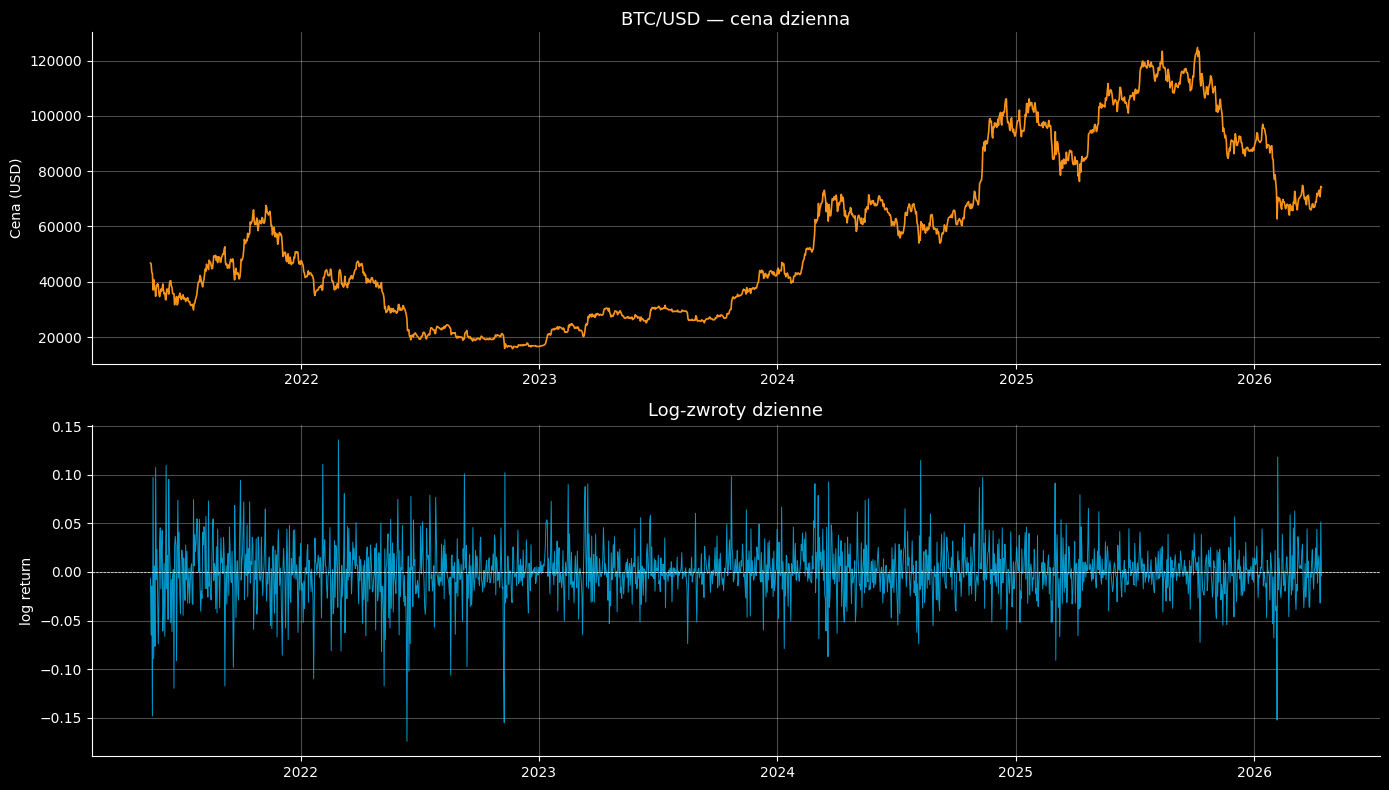

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(price.index, price, color='#F7931A', linewidth=1.2)
axes[0].set_title('BTC/USD — cena dzienna', fontsize=13)
axes[0].set_ylabel('Cena (USD)')

axes[1].plot(log_ret.index, log_ret, color='#00BFFF', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_title('Log-zwroty dzienne', fontsize=13)
axes[1].set_ylabel('log return')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 3. Test stacjonarności ADF

ARIMA wymaga stacjonarnego szeregu — **ceny z reguły nim nie są** (trend). Parametr `d` w ARIMA(p,d,q) to liczba różnicowań potrzebna do uzyskania stacjonarności.

In [18]:
def adf_test(series, name):
    res = adfuller(series.dropna())
    status = '✅ STACJONARNY' if res[1] <= 0.05 else 'NIESTACJONARNY'
    print(f'{status:25s}  p={res[1]:.4f}  ADF={res[0]:.3f}  →  {name}')
    return res[1]

print('Wyniki testu ADF (H0: szereg niestacjonarny):')
print('-' * 65)
adf_test(price,          'Ceny BTC (poziomy)       → oczekiwane: niestacjonarne')
adf_test(price.diff(),   'Ceny BTC (1. różnica)    → oczekiwane: stacjonarne → d=1')
adf_test(log_ret,        'Log-zwroty               → zwykle stacjonarne')

Wyniki testu ADF (H0: szereg niestacjonarny):
-----------------------------------------------------------------
NIESTACJONARNY             p=0.7457  ADF=-1.021  →  Ceny BTC (poziomy)       → oczekiwane: niestacjonarne
✅ STACJONARNY              p=0.0000  ADF=-44.554  →  Ceny BTC (1. różnica)    → oczekiwane: stacjonarne → d=1
✅ STACJONARNY              p=0.0000  ADF=-44.171  →  Log-zwroty               → zwykle stacjonarne


0.0

---
## 4. ACF / PACF — diagnostyka opóźnień

- **ACF** (górny) → dobór `q` (rząd MA): ile opóźnień wychodzi poza przedział ufności
- **PACF** (dolny) → dobór `p` (rząd AR): j.w.

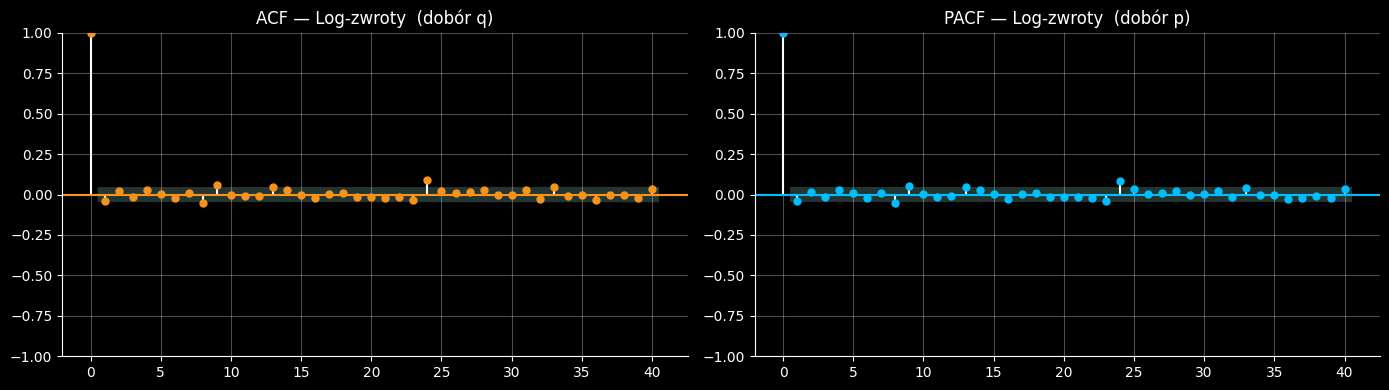

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(log_ret, lags=40, ax=axes[0], color='#F7931A', alpha=0.05)
axes[0].set_title('ACF — Log-zwroty  (dobór q)', fontsize=12)

plot_pacf(log_ret, lags=40, ax=axes[1], color='#00BFFF', method='ywm', alpha=0.05)
axes[1].set_title('PACF — Log-zwroty  (dobór p)', fontsize=12)

plt.tight_layout()
plt.show()

---
## 5. Dobór parametrów ARIMA — Grid Search (kryterium AIC)

Przeszukujemy siatkę `p ∈ {0..4}`, `d=1`, `q ∈ {0..4}` → wybieramy model z najniższym AIC.

In [20]:
results = []
candidates = list(product(range(0, 5), [1], range(0, 5)))  # 25 kombinacji
print(f'Testuję {len(candidates)} kombinacji ARIMA(p,1,q)...')

for i, (p, d, q) in enumerate(candidates):
    try:
        fit = ARIMA(price, order=(p, d, q)).fit()
        results.append({'p': p, 'd': d, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic})
    except Exception:
        pass
    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{len(candidates)}...', end='\r')

res_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)

print('\n\nTop 8 modeli wg AIC:')
print(res_df.head(8).to_string(index=False))

best = res_df.iloc[0]
BEST_ORDER = (int(best.p), int(best.d), int(best.q))
print(f'\n✅  Wybrany model: ARIMA{BEST_ORDER}   AIC={best.AIC:.2f}')

Testuję 25 kombinacji ARIMA(p,1,q)...
  25/25...

Top 8 modeli wg AIC:
 p  d  q          AIC          BIC
 4  1  1 31603.668794 31636.625356
 1  1  4 31604.496991 31637.453553
 2  1  4 31604.780767 31643.230089
 4  1  2 31604.787570 31643.236892
 3  1  4 31606.746665 31650.688748
 4  1  4 31607.784866 31657.219709
 4  1  3 31608.528581 31652.470663
 1  1  3 31608.550587 31636.014389

✅  Wybrany model: ARIMA(4, 1, 1)   AIC=31603.67


---
## 6. Walk-Forward Validation — ocena dokładności krótkoterminowej

**Dlaczego walk-forward, nie train/test split?**  
W zwykłym splicie model "widzi" przyszłe dane podczas treningu → zawyżona dokładność. Walk-forward trenuje model na każdym kroku tylko na danych z przeszłości.

Testujemy na **ostatnich 180 dniach** prognozami 1-dniowymi naprzód.

In [21]:
TEST_DAYS = 180

train = price.iloc[:-TEST_DAYS]
test  = price.iloc[-TEST_DAYS:]

print(f'Trening: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} dni)')
print(f'Test:    {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} dni)')
print(f'Model:   ARIMA{BEST_ORDER}')
print('\nUruchamiam walk-forward...')

history = list(train)
preds_1d = []

for i, actual in enumerate(test):
    try:
        pred = ARIMA(history, order=BEST_ORDER).fit().forecast(steps=1)[0]
    except Exception:
        pred = history[-1]
    preds_1d.append(pred)
    history.append(actual)
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{TEST_DAYS} dni...', end='\r')

pred_1d = pd.Series(preds_1d, index=test.index)
print('\n✅ Gotowe!')

Trening: 2021-05-15 → 2025-10-16  (1616 dni)
Test:    2025-10-17  → 2026-04-14   (180 dni)
Model:   ARIMA(4, 1, 1)

Uruchamiam walk-forward...
  180/180 dni...
✅ Gotowe!


---
## 7. Metryki dokładności (1-dniowa prognoza)

In [22]:
def metrics(actual, predicted, label):
    a, p = np.array(actual), np.array(predicted)
    mae  = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    mape = np.mean(np.abs((a - p) / a)) * 100
    # Directional accuracy: trafienie kierunku zmiany ceny
    actual_dir = np.sign(np.diff(a))
    pred_dir   = np.sign(np.diff(p))
    da = np.mean(actual_dir == pred_dir) * 100
    print(f'┌─ Metryki: {label} {"─"*(40-len(label))}')
    print(f'│  MAE:               ${mae:>10,.0f}')
    print(f'│  RMSE:              ${rmse:>10,.0f}')
    print(f'│  MAPE:              {mape:>10.2f}%   (średni błąd procentowy)')
    print(f'│  Directional Acc.:  {da:>10.1f}%   (trafienie kierunku ruchu)')
    print(f'└{"─"*50}')
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, DA=da)

m1d = metrics(test, pred_1d, 'prognoza 1 dzień naprzód (180-dniowy test)')

┌─ Metryki: prognoza 1 dzień naprzód (180-dniowy test) 
│  MAE:               $     1,517
│  RMSE:              $     2,104
│  MAPE:                    1.85%   (średni błąd procentowy)
│  Directional Acc.:        52.0%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────


---
## 8. Wizualizacja walk-forward (1 dzień)

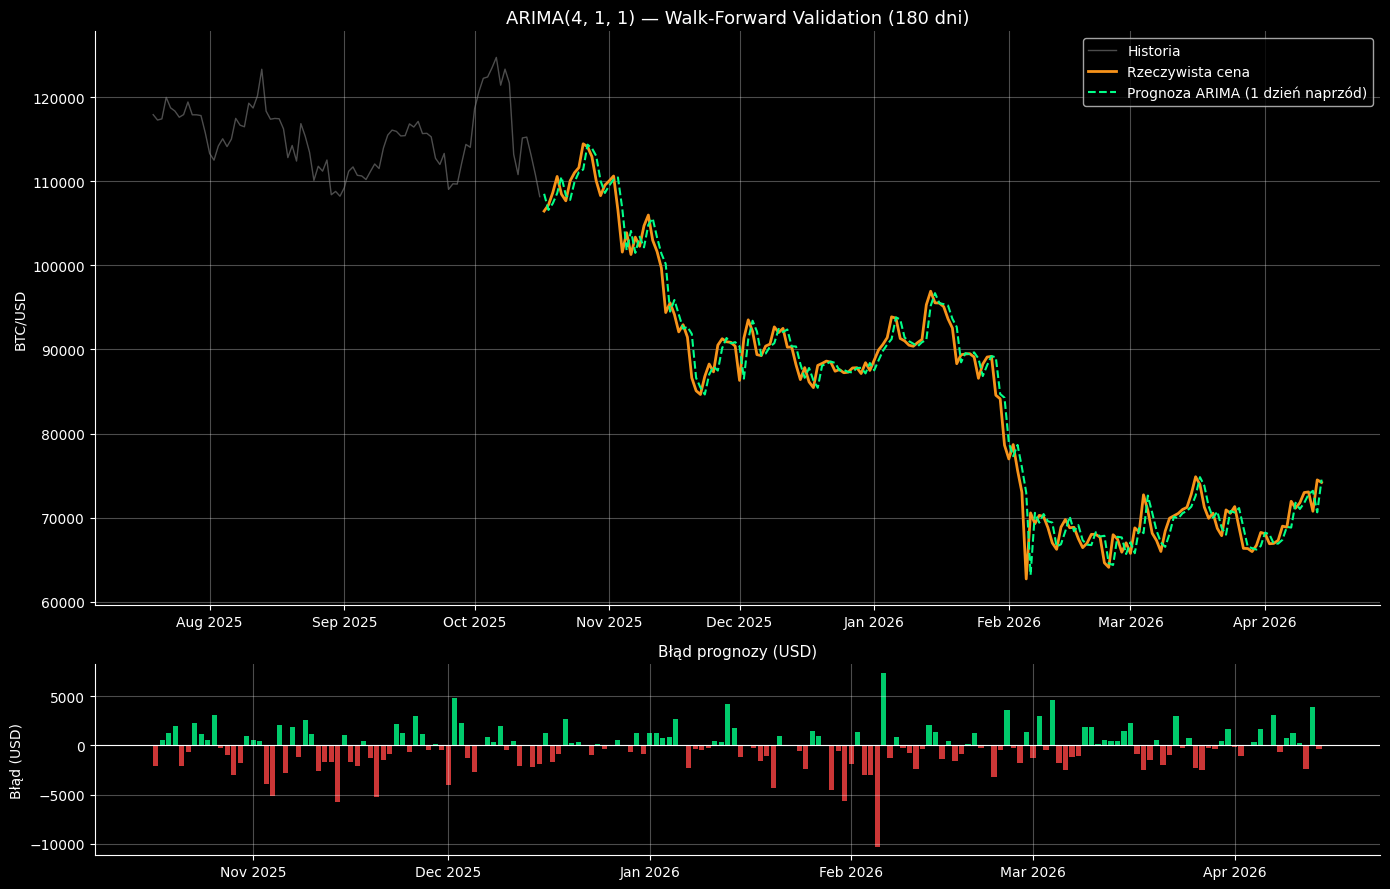

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(train.index[-90:], train.iloc[-90:], color='gray', lw=1, alpha=0.6, label='Historia')
ax1.plot(test.index, test.values, color='#F7931A', lw=2, label='Rzeczywista cena')
ax1.plot(pred_1d.index, pred_1d.values, color='#00FF88', lw=1.5,
         linestyle='--', label='Prognoza ARIMA (1 dzień naprzód)')
ax1.set_title(f'ARIMA{BEST_ORDER} — Walk-Forward Validation ({TEST_DAYS} dni)', fontsize=13)
ax1.set_ylabel('BTC/USD')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax2 = axes[1]
err = test.values - pred_1d.values
colors = np.where(err >= 0, '#00FF88', '#FF4444')
ax2.bar(test.index, err, color=colors, width=0.8, alpha=0.8)
ax2.axhline(0, color='white', lw=0.8)
ax2.set_title('Błąd prognozy (USD)', fontsize=11)
ax2.set_ylabel('Błąd (USD)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../data/processed/arima_walkforward.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Finalny model — trening na całych danych

Do prognozowania w przyszłość trenujemy model na **wszystkich dostępnych danych**.

In [24]:
print(f'Trenuję ARIMA{BEST_ORDER} na {len(price)} dniach danych...')
final_fit = ARIMA(price, order=BEST_ORDER).fit()
print(f'✅ Model wytrenowany.')
print(f'   AIC: {final_fit.aic:.2f}   BIC: {final_fit.bic:.2f}')
print(f'   Ostatnia znana cena: ${price.iloc[-1]:,.0f}  ({price.index[-1].date()})')

Trenuję ARIMA(4, 1, 1) na 1796 dniach danych...
✅ Model wytrenowany.
   AIC: 31603.67   BIC: 31636.63
   Ostatnia znana cena: $74,182  (2026-04-14)


---
## 10. Prognoza na wszystkie horyzonty

ARIMA generuje prognozy sekwencyjnie — każdy kolejny krok bazuje na poprzednim. Przedział ufności (CI) rośnie wraz z horyzontem.

In [25]:
HORIZONS = {
    'Jutro':      1,
    '3 dni':      3,
    '7 dni':      7,
    '14 dni':     14,
    'Miesiąc':    30,
    '3 miesiące': 90,
    '6 miesięcy': 180,
}

MAX_STEPS = max(HORIZONS.values())  # 180
last_date = price.index[-1]
last_price = price.iloc[-1]

# Jedna prognoza na 180 kroków do przodu — wycinamy podzbiory
forecast_obj  = final_fit.get_forecast(steps=MAX_STEPS)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=MAX_STEPS, freq='D')
forecast_mean.index = future_dates
forecast_ci.index   = future_dates

# Tabela wyników
print(f'Ostatnia znana cena: ${last_price:,.0f}  ({last_date.date()})')
print()
print(f'{"Horyzont":<14} {"Dzień":^12} {"Prognoza":>12} {"Zmiana":>9} {"CI dolny":>12} {"CI górny":>12} {"Szerokość CI":>14}')
print('─' * 90)

summary_rows = []
for name, steps in HORIZONS.items():
    target_date = future_dates[steps - 1]
    pred_val    = forecast_mean.iloc[steps - 1]
    ci_lo       = forecast_ci.iloc[steps - 1, 0]
    ci_hi       = forecast_ci.iloc[steps - 1, 1]
    change_pct  = (pred_val / last_price - 1) * 100
    ci_width    = ci_hi - ci_lo
    sign        = '+' if change_pct >= 0 else ''
    print(f'{name:<14} {str(target_date.date()):^12} {pred_val:>12,.0f} {sign+f"{change_pct:.1f}%":>9} '
          f'{ci_lo:>12,.0f} {ci_hi:>12,.0f} {ci_width:>14,.0f}')
    summary_rows.append(dict(horyzont=name, dni=steps, prognoza=pred_val,
                              zmiana_pct=change_pct, ci_lo=ci_lo, ci_hi=ci_hi))

summary_df = pd.DataFrame(summary_rows)

Ostatnia znana cena: $74,182  (2026-04-14)

Horyzont          Dzień         Prognoza    Zmiana     CI dolny     CI górny   Szerokość CI
──────────────────────────────────────────────────────────────────────────────────────────
Jutro           2026-04-15        74,031     -0.2%       70,886       77,176          6,290
3 dni           2026-04-17        73,845     -0.5%       68,590       79,101         10,511
7 dni           2026-04-21        73,920     -0.4%       66,203       81,638         15,435
14 dni          2026-04-28        74,039     -0.2%       63,271       84,806         21,535
Miesiąc         2026-05-14        74,014     -0.2%       58,383       89,645         31,262
3 miesiące      2026-07-13        74,013     -0.2%       47,069      100,956         53,887
6 miesięcy      2026-10-11        74,013     -0.2%       35,955      112,070         76,115


---
## 11. Wykresy prognoz — wszystkie horyzonty

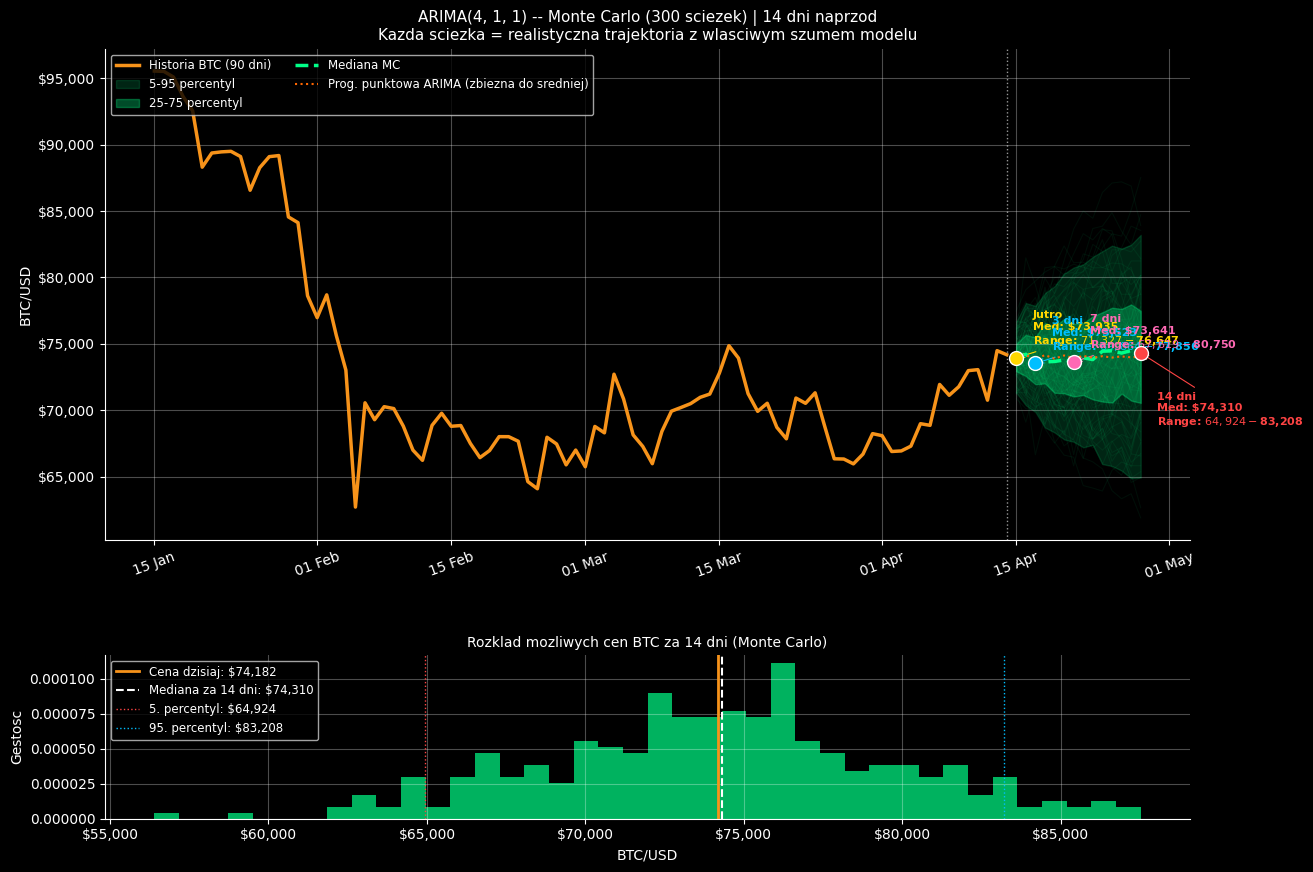

Monte Carlo (300 sciezek) -- rozklad cen za 14 dni:
  Cena dzisiaj:   $74,182
  Mediana:        $74,310
  5. percentyl:   $64,924  (scenariusz pesymistyczny)
  95. percentyl:  $83,208  (scenariusz optymistyczny)
  Prob. wzrostu:  51.0%
  Prob. >+5%:     22.3%
  Prob. <-5%:     24.3%


In [26]:
# Monte Carlo -- symulacja 300 mozliwych sciezek cenowych z modelu ARIMA
# Dlaczego MC zamiast punktowej prognozy?
# Punktowa prognoza ARIMA zawsze zbiega do sredniej (plaska linia) -- to matematyczna wlasciwosc.
# Monte Carlo pokazuje REALNE mozliwe trajektorie: kazda sciezka ma wzrosty i spadki.

N_SIMS  = 300
N_STEPS = 14
np.random.seed(42)
sigma   = np.std(final_fit.resid)   # odch. std reszt modelu

# Generowanie sciezek symulacyjnych
sim_paths = []
for i in range(N_SIMS):
    try:
        path = final_fit.simulate(
            nsimulations=N_STEPS,
            anchor='end',
            random_state=np.random.RandomState(i)
        ).values
    except Exception:
        # Fallback: reczna symulacja przez roznicowanie
        last_vals = list(price.iloc[-10:].values)
        path = []
        for _ in range(N_STEPS):
            fc = ARIMA(last_vals, order=BEST_ORDER).fit().forecast(steps=1)[0]
            noise = np.random.normal(0, sigma)
            val = fc + noise
            path.append(val)
            last_vals.append(val)
            last_vals.pop(0)
        path = np.array(path)
    sim_paths.append(path)

sim_paths = np.array(sim_paths)  # shape: (300, 14)

# Statystyki sciezek
pct_5   = np.percentile(sim_paths, 5,  axis=0)
pct_25  = np.percentile(sim_paths, 25, axis=0)
pct_50  = np.percentile(sim_paths, 50, axis=0)
pct_75  = np.percentile(sim_paths, 75, axis=0)
pct_95  = np.percentile(sim_paths, 95, axis=0)

future_14 = future_dates[:N_STEPS]

# ── Wykres ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})

ax1 = axes[0]

# Historia
hist_slice = price.iloc[-90:]
ax1.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2.5, zorder=5,
         label='Historia BTC (90 dni)')
ax1.axvline(last_date, color='white', lw=1, linestyle=':', alpha=0.6)

# Sciezki MC (losowa probka 80 sciezek dla czytelnosci)
idx_sample = np.random.choice(N_SIMS, size=80, replace=False)
for i in idx_sample:
    ax1.plot(future_14, sim_paths[i], color='#00FF88', alpha=0.06, lw=0.8)

# Percentyle
ax1.fill_between(future_14, pct_5,  pct_95, alpha=0.15, color='#00FF88', label='5-95 percentyl')
ax1.fill_between(future_14, pct_25, pct_75, alpha=0.30, color='#00FF88', label='25-75 percentyl')
ax1.plot(future_14, pct_50, color='#00FF88', lw=2.5, linestyle='--', zorder=6,
         label='Mediana MC')

# Punktowa prognoza ARIMA (dla porownania -- plaska linia)
mean_14 = forecast_mean.iloc[:N_STEPS].values
ax1.plot(future_14, mean_14, color='#FF6600', lw=1.5, linestyle=':', zorder=7,
         label='Prog. punktowa ARIMA (zbiezna do sredniej)')

# Oznaczenia horyzontow
HORIZONS_SHORT = {'Jutro': 1, '3 dni': 3, '7 dni': 7, '14 dni': 14}
COLORS_SHORT   = ['#FFD700', '#00BFFF', '#FF69B4', '#FF4444']
for (name, steps), color in zip(HORIZONS_SHORT.items(), COLORS_SHORT):
    d  = future_dates[steps - 1]
    lo = np.percentile(sim_paths[:, steps-1], 5)
    hi = np.percentile(sim_paths[:, steps-1], 95)
    me = np.percentile(sim_paths[:, steps-1], 50)
    ax1.scatter([d], [me], color=color, s=100, zorder=10, edgecolors='white', lw=1)
    ax1.annotate(
        f'{name}\nMed: ${me:,.0f}\nRange: ${lo:,.0f}-${hi:,.0f}',
        xy=(d, me), xytext=(12, 10 if steps <= 7 else -52),
        textcoords='offset points', fontsize=8, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=0.8)
    )

ax1.set_title(
    f'ARIMA{BEST_ORDER} -- Monte Carlo ({N_SIMS} sciezek) | 14 dni naprzod\n'
    f'Kazda sciezka = realistyczna trajektoria z wlasciwym szumem modelu',
    fontsize=11
)
ax1.set_ylabel('BTC/USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=8.5, loc='upper left', ncol=2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.tick_params(axis='x', rotation=20)

# ── Dolny wykres: rozklad koncowych cen po 14 dniach ──
ax2 = axes[1]
final_prices = sim_paths[:, -1]
ax2.hist(final_prices, bins=40, color='#00FF88', alpha=0.7, edgecolor='none', density=True)
ax2.axvline(last_price, color='#F7931A', lw=2, label=f'Cena dzisiaj: ${last_price:,.0f}')
ax2.axvline(np.percentile(final_prices, 50), color='white', lw=1.5, linestyle='--',
            label=f'Mediana za 14 dni: ${np.percentile(final_prices,50):,.0f}')
ax2.axvline(np.percentile(final_prices, 5),  color='#FF4444', lw=1, linestyle=':',
            label=f'5. percentyl: ${np.percentile(final_prices,5):,.0f}')
ax2.axvline(np.percentile(final_prices, 95), color='#00BFFF', lw=1, linestyle=':',
            label=f'95. percentyl: ${np.percentile(final_prices,95):,.0f}')
ax2.set_title('Rozklad mozliwych cen BTC za 14 dni (Monte Carlo)', fontsize=10)
ax2.set_xlabel('BTC/USD')
ax2.set_ylabel('Gestosc')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=8.5)

plt.savefig('../data/processed/arima_montecarlo_14d.png', dpi=130, bbox_inches='tight')
plt.show()

# Podsumowanie liczbowe
print(f'Monte Carlo ({N_SIMS} sciezek) -- rozklad cen za 14 dni:')
print(f'  Cena dzisiaj:   ${last_price:,.0f}')
print(f'  Mediana:        ${np.percentile(final_prices,50):,.0f}')
print(f'  5. percentyl:   ${np.percentile(final_prices,5):,.0f}  (scenariusz pesymistyczny)')
print(f'  95. percentyl:  ${np.percentile(final_prices,95):,.0f}  (scenariusz optymistyczny)')
print(f'  Prob. wzrostu:  {np.mean(final_prices > last_price)*100:.1f}%')
print(f'  Prob. >+5%:     {np.mean(final_prices > last_price*1.05)*100:.1f}%')
print(f'  Prob. <-5%:     {np.mean(final_prices < last_price*0.95)*100:.1f}%')


---
## 11b. Eksperyment -- ARIMA z duzym p (wiecej pamieci historycznej)

Sprawdzamy czy wiekszy rzad AR (p=30, 90, 180) daje bardziej zroznicowane prognozy
niz ARIMA(4,1,2) wybrany przez AIC.

| Model | Pamiec | Oczekiwany efekt |
|---|---|---|
| ARIMA(4,1,2) | 4 dni | Baseline (AIC-optimal) |
| ARIMA(30,1,0) | 30 dni | Miesiac wstecz |
| ARIMA(90,1,0) | 90 dni | Kwartal wstecz |
| ARIMA(180,1,0) | 180 dni | Pol roku wstecz |

> **Uwaga:** Duze p = dlugi czas treningu i ryzyko braku zbieznosci.

In [27]:
# Trenowanie modeli z duzym p
# Uzywamy tylko AR (q=0) zeby uniknac problemow numerycznych przy duzym p

HIGH_P_MODELS = {
    f'ARIMA{BEST_ORDER} (AIC-opt)': BEST_ORDER,
    'ARIMA(30,1,0)':  (30,  1, 0),
    'ARIMA(90,1,0)':  (90,  1, 0),
}

fitted_models = {}
aic_scores    = {}

for name, order in HIGH_P_MODELS.items():
    print(f'Trenuje {name}...', end=' ')
    try:
        fit = ARIMA(price, order=order).fit(method_kwargs={'warn_convergence': False})
        fitted_models[name] = fit
        aic_scores[name]    = fit.aic
        print(f'OK  AIC={fit.aic:.1f}')
    except Exception as e:
        print(f'BLAD: {e}')

print()
print('Porownanie AIC (nizsze = lepsze dopasowanie do danych):')
for name, aic in sorted(aic_scores.items(), key=lambda x: x[1]):
    marker = ' <-- wybrany przez grid search' if 'AIC-opt' in name else ''
    print(f'  {name:<28} AIC={aic:,.1f}{marker}')

Trenuje ARIMA(4, 1, 1) (AIC-opt)... OK  AIC=31603.7
Trenuje ARIMA(30,1,0)... OK  AIC=31623.8
Trenuje ARIMA(90,1,0)... OK  AIC=31670.0

Porownanie AIC (nizsze = lepsze dopasowanie do danych):
  ARIMA(4, 1, 1) (AIC-opt)     AIC=31,603.7 <-- wybrany przez grid search
  ARIMA(30,1,0)                AIC=31,623.8
  ARIMA(90,1,0)                AIC=31,670.0


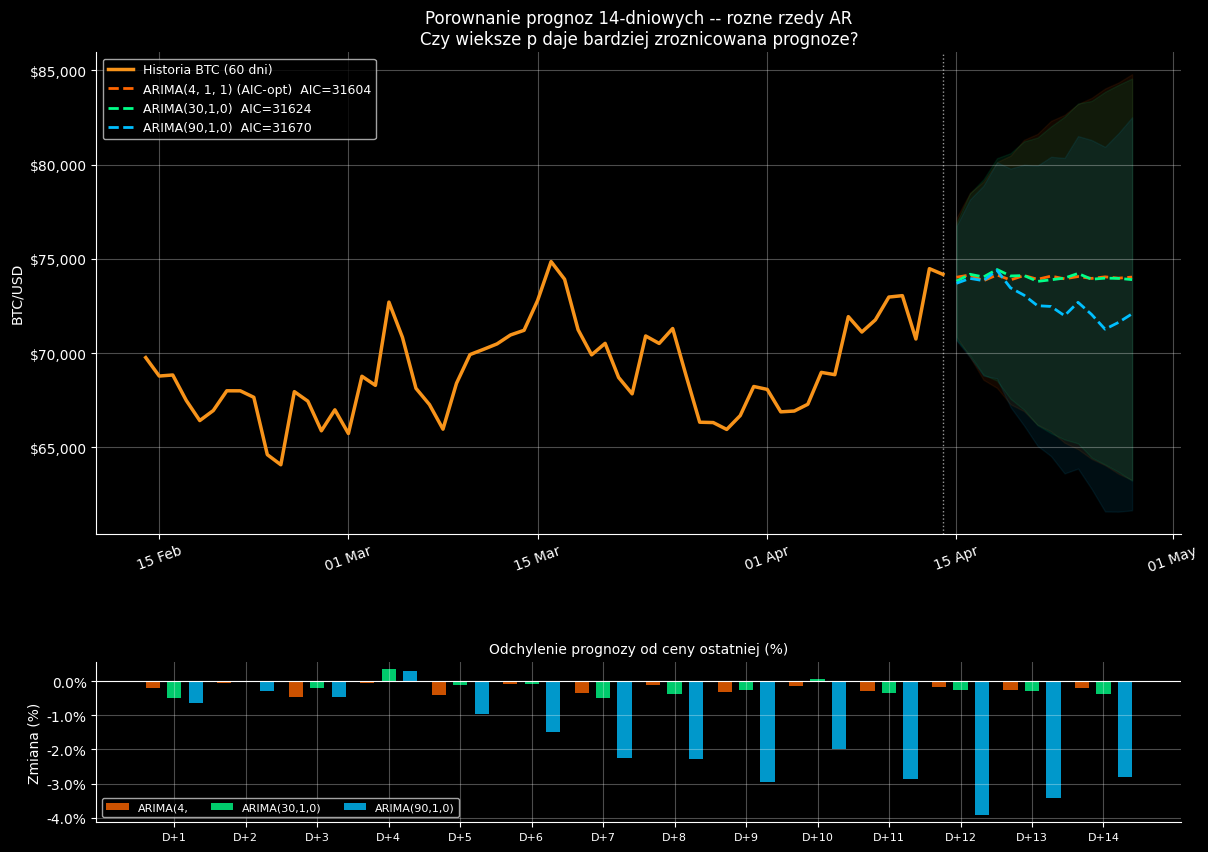

In [28]:
# Porownanie prognoz 14-dniowych
N_STEPS   = 14
future_14 = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=N_STEPS, freq='D')

MODEL_COLORS = {
    f'ARIMA{BEST_ORDER} (AIC-opt)': '#FF6600',
    'ARIMA(30,1,0)':  '#00FF88',
    'ARIMA(90,1,0)':  '#00BFFF',
    'ARIMA(180,1,0)': '#FF69B4',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.4})

ax1 = axes[0]

# Historia
hist_slice = price.iloc[-60:]
ax1.plot(hist_slice.index, hist_slice.values,
         color='#F7931A', lw=2.5, zorder=5, label='Historia BTC (60 dni)')
ax1.axvline(last_date, color='white', lw=1, linestyle=':', alpha=0.6)

# Prognoza kazdego modelu + 95% CI
forecasts = {}
for name, fit in fitted_models.items():
    color = MODEL_COLORS[name]
    try:
        fc   = fit.get_forecast(steps=N_STEPS)
        mean = fc.predicted_mean.values
        ci   = fc.conf_int(alpha=0.05)
        forecasts[name] = mean
        ax1.plot(future_14, mean, color=color, lw=2, linestyle='--',
                 zorder=6, label=f'{name}  AIC={aic_scores.get(name,"?"):.0f}')
        ax1.fill_between(future_14, ci.iloc[:, 0], ci.iloc[:, 1],
                         alpha=0.08, color=color)
    except Exception as e:
        print(f'Blad prognozy {name}: {e}')

ax1.set_title('Porownanie prognoz 14-dniowych -- rozne rzedy AR\n'
              'Czy wieksze p daje bardziej zroznicowana prognoze?', fontsize=12)
ax1.set_ylabel('BTC/USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.tick_params(axis='x', rotation=20)

# Dolny wykres: roznica prognoz od ceny ostatniej (%)
ax2 = axes[1]
x = np.arange(N_STEPS)
width = 0.2
offsets = np.linspace(-0.3, 0.3, len(forecasts))

for (name, mean), offset, color in zip(forecasts.items(), offsets, MODEL_COLORS.values()):
    pct_diff = (mean / last_price - 1) * 100
    ax2.bar(x + offset, pct_diff, width=width, color=color, alpha=0.8,
            label=name.split(' ')[0])

ax2.axhline(0, color='white', lw=0.8)
ax2.set_title('Odchylenie prognozy od ceny ostatniej (%)', fontsize=10)
ax2.set_ylabel('Zmiana (%)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'D+{i+1}' for i in x], fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.legend(fontsize=8, ncol=4)

plt.savefig('../data/processed/arima_highp_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [29]:
# Analiza: na ile kroki prognoza przestaje byc plaska?
print('Analiza plaskosci prognoz (odch. std wartosci prognozy):')
print('Im nizsze odchylenie, tym bardziej plaska linia.')
print()
print(f'{"Model":<28} {"std prognozy":>14} {"max zmiana":>12} {"min":>12} {"max":>12}')
print('-' * 75)
for name, mean in forecasts.items():
    std_pred   = np.std(mean)
    max_change = (np.max(mean) / np.min(mean) - 1) * 100
    print(f'{name:<28} ${std_pred:>12,.0f} {max_change:>11.2f}%  ${np.min(mean):>10,.0f}  ${np.max(mean):>10,.0f}')

print()
print('Wniosek: jesli std prognozy jest mala (~0-100), linia jest praktycznie plaska.')
print('Nawet ARIMA(180,1,0) zbiega do sredniej po kilku krokach.')
print()
print('To jest matematyczna wlasciwosc ARIMA na danych finansowych (random walk).')
print('Rozwiazanie: LSTM/BiLSTM -- modele nieliniowe z dluga pamiecia (BPTT).')

Analiza plaskosci prognoz (odch. std wartosci prognozy):
Im nizsze odchylenie, tym bardziej plaska linia.

Model                          std prognozy   max zmiana          min          max
---------------------------------------------------------------------------
ARIMA(4, 1, 1) (AIC-opt)     $          93        0.42%  $    73,845  $    74,152
ARIMA(30,1,0)                $         168        0.86%  $    73,811  $    74,443
ARIMA(90,1,0)                $         924        4.38%  $    71,274  $    74,396

Wniosek: jesli std prognozy jest mala (~0-100), linia jest praktycznie plaska.
Nawet ARIMA(180,1,0) zbiega do sredniej po kilku krokach.

To jest matematyczna wlasciwosc ARIMA na danych finansowych (random walk).
Rozwiazanie: LSTM/BiLSTM -- modele nieliniowe z dluga pamiecia (BPTT).


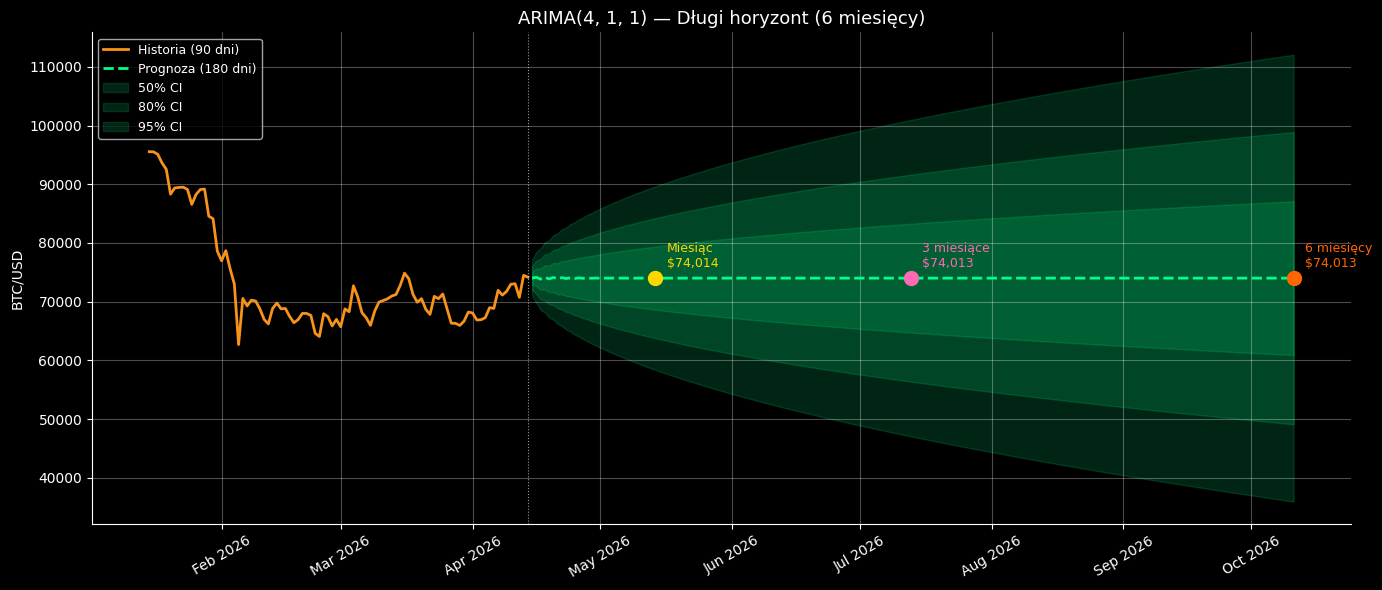

In [30]:
# ── Wykres 2: Długi horyzont (miesiąc / 3 mies. / 6 mies.) ──
fig, ax = plt.subplots(figsize=(14, 6))

hist_slice = price.iloc[-90:]
ax.plot(hist_slice.index, hist_slice.values, color='#F7931A', lw=2, label='Historia (90 dni)')
ax.plot(future_dates, forecast_mean.values, color='#00FF88', lw=2, linestyle='--', label='Prognoza (180 dni)')

# Przedziały ufności 50%, 80%, 95%
for alpha, label in [(0.50, '50% CI'), (0.80, '80% CI'), (0.95, '95% CI')]:
    ci_tmp = final_fit.get_forecast(steps=MAX_STEPS).conf_int(alpha=1 - alpha)
    ci_tmp.index = future_dates
    ax.fill_between(future_dates, ci_tmp.iloc[:, 0], ci_tmp.iloc[:, 1],
                    alpha=0.15, color='#00FF88', label=label)

ax.axvline(last_date, color='white', lw=0.8, linestyle=':', alpha=0.6)

LONG = ['Miesiąc', '3 miesiące', '6 miesięcy']
LONG_COLORS = ['#FFD700', '#FF69B4', '#FF6600']
for name, color in zip(LONG, LONG_COLORS):
    steps = HORIZONS[name]
    d = future_dates[steps - 1]
    v = forecast_mean.iloc[steps - 1]
    ax.scatter([d], [v], color=color, s=100, zorder=5)
    ax.annotate(f'{name}\n${v:,.0f}', xy=(d, v), xytext=(8, 8),
                textcoords='offset points', fontsize=9, color=color)

ax.set_title(f'ARIMA{BEST_ORDER} — Długi horyzont (6 miesięcy)', fontsize=13)
ax.set_ylabel('BTC/USD')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/arima_forecast_long.png', dpi=120, bbox_inches='tight')
plt.show()

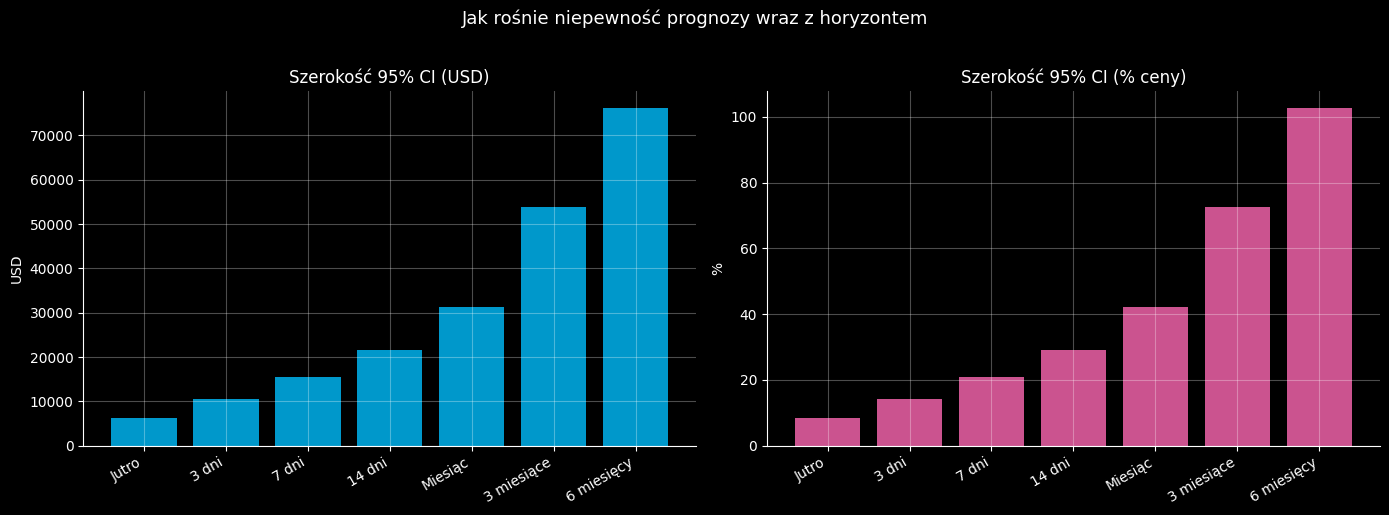

Interpretacja: ARIMA jest modelem krótkoterminowym.
Na horyzoncie >30 dni CI staje się bardzo szeroki — prognoza jest mało precyzyjna.


In [31]:
# ── Wykres 3: Szerokość CI vs horyzont (jak rośnie niepewność) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ci_widths  = [summary_df.loc[summary_df.horyzont==n, 'ci_hi'].values[0] -
              summary_df.loc[summary_df.horyzont==n, 'ci_lo'].values[0]
              for n in HORIZONS]
ci_widths_pct = [w / last_price * 100 for w in ci_widths]
labels = list(HORIZONS.keys())
x = range(len(labels))

axes[0].bar(x, ci_widths, color='#00BFFF', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_title('Szerokość 95% CI (USD)', fontsize=12)
axes[0].set_ylabel('USD')

axes[1].bar(x, ci_widths_pct, color='#FF69B4', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_title('Szerokość 95% CI (% ceny)', fontsize=12)
axes[1].set_ylabel('%')

plt.suptitle('Jak rośnie niepewność prognozy wraz z horyzontem', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/arima_ci_width.png', dpi=120, bbox_inches='tight')
plt.show()

print('Interpretacja: ARIMA jest modelem krótkoterminowym.')
print('Na horyzoncie >30 dni CI staje się bardzo szeroki — prognoza jest mało precyzyjna.')

---
## 12. Diagnostyka reszt modelu

Sprawdzamy czy reszty (błędy) wyglądają jak **biały szum** — jeśli tak, model dobrze uchwycił strukturę danych.

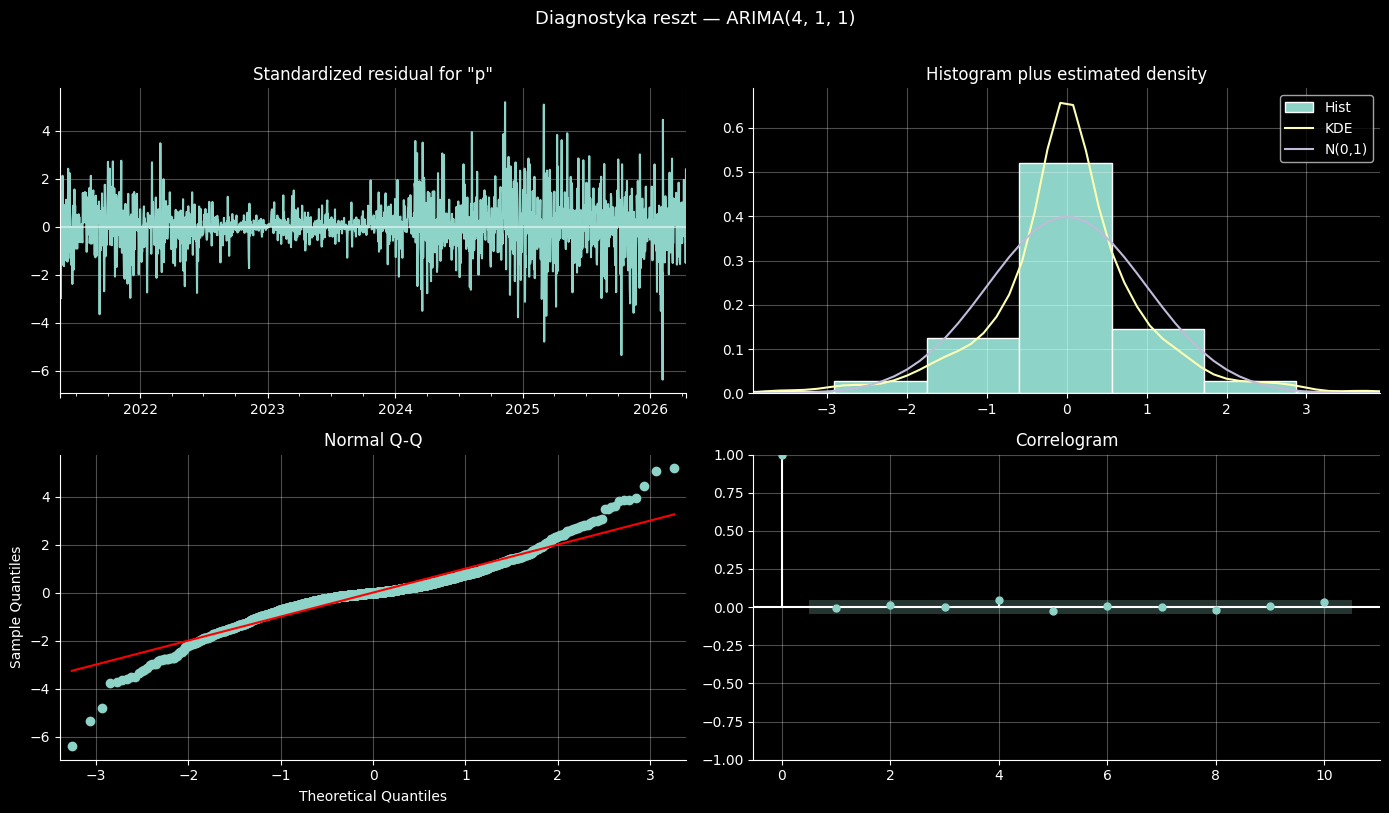

Co sprawdzamy:
  Standardized residuals → brak wzorców (losowe odchylenia wokół 0)
  Histogram + KDE        → rozkład zbliżony do normalnego
  Q-Q plot               → punkty blisko prostej = reszty normalne
  Correlogram (ACF)      → wszystkie słupki w przedziale ufności = brak autokorelacji


In [32]:
fig = final_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnostyka reszt — ARIMA{BEST_ORDER}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Co sprawdzamy:')
print('  Standardized residuals → brak wzorców (losowe odchylenia wokół 0)')
print('  Histogram + KDE        → rozkład zbliżony do normalnego')
print('  Q-Q plot               → punkty blisko prostej = reszty normalne')
print('  Correlogram (ACF)      → wszystkie słupki w przedziale ufności = brak autokorelacji')

---
## 13. Podsumowanie końcowe

In [33]:
print('=' * 65)
print('              PODSUMOWANIE — ARIMA Bitcoin')
print('=' * 65)
print(f'Model:         ARIMA{BEST_ORDER}')
print(f'Dane:          {price.index[0].date()} → {price.index[-1].date()}  ({len(price)} dni)')
print(f'Ostatnia cena: ${last_price:,.0f}  ({last_date.date()})')
print()
print('Dokładność (walk-forward, ostatnie 180 dni):')
print(f'  MAPE:             {m1d["MAPE"]:.2f}%')
print(f'  MAE:              ${m1d["MAE"]:,.0f}')
print(f'  RMSE:             ${m1d["RMSE"]:,.0f}')
print(f'  Directional Acc.: {m1d["DA"]:.1f}%')
print()
print('Prognoza cenowa:')
print(f'{"Horyzont":<14} {"Prognoza":>12} {"Zmiana":>9} {"95% CI":>28}')
print('-' * 68)
for _, row in summary_df.iterrows():
    sign = '+' if row.zmiana_pct >= 0 else ''
    print(f'{row.horyzont:<14} ${row.prognoza:>11,.0f} {sign+f"{row.zmiana_pct:.1f}%":>9}  '
          f'[${row.ci_lo:,.0f} ; ${row.ci_hi:,.0f}]')
print()
print('Ograniczenia ARIMA:')
print('  • Liniowy — nie uchwyci nieliniowych wzorców (boom/crash)')
print('  • Univariate — nie korzysta z danych on-chain')
print('  • CI rośnie bardzo szybko — >30 dni to prognoza poglądowa')
print('  • Nie modeluje zmienności (heteroskedastyczności)')
print()
print('Następny krok: LSTM/BiLSTM — modele nieliniowe,')
print('które mogą korzystać z pełnego zestawu cech on-chain.')
print('=' * 65)

              PODSUMOWANIE — ARIMA Bitcoin
Model:         ARIMA(4, 1, 1)
Dane:          2021-05-15 → 2026-04-14  (1796 dni)
Ostatnia cena: $74,182  (2026-04-14)

Dokładność (walk-forward, ostatnie 180 dni):
  MAPE:             1.85%
  MAE:              $1,517
  RMSE:             $2,104
  Directional Acc.: 52.0%

Prognoza cenowa:
Horyzont           Prognoza    Zmiana                       95% CI
--------------------------------------------------------------------
Jutro          $     74,031     -0.2%  [$70,886 ; $77,176]
3 dni          $     73,845     -0.5%  [$68,590 ; $79,101]
7 dni          $     73,920     -0.4%  [$66,203 ; $81,638]
14 dni         $     74,039     -0.2%  [$63,271 ; $84,806]
Miesiąc        $     74,014     -0.2%  [$58,383 ; $89,645]
3 miesiące     $     74,013     -0.2%  [$47,069 ; $100,956]
6 miesięcy     $     74,013     -0.2%  [$35,955 ; $112,070]

Ograniczenia ARIMA:
  • Liniowy — nie uchwyci nieliniowych wzorców (boom/crash)
  • Univariate — nie korzysta z danyc

---
## 14. ARIMAX -- ARIMA z danymi on-chain (zmienne egzogeniczne)

**Czym rozni sie ARIMAX od ARIMA?**
ARIMAX = ARIMA + **exog** -- model uczy sie wplywu zewnetrznych szergow (danych on-chain) na cene BTC.

### Strategia: opoznione zmienne egzogeniczne (lag=1)
Uzywamy wartosci on-chain **z dnia poprzedniego** do prognozowania ceny **dzisiejszej**.
Dzieki temu:
- Brak look-ahead bias (nie uzywamy przyszlych danych)
- Przy prognozie jutrzejszej znamy juz dzisiejsze dane on-chain

### Uzyte zmienne (wszystkie z `bitcoin_final.csv`)
| Zmienna | Odpowiada wymaganiu ze screenshota |
|---|---|
| `active_addresses` | Liczba aktywnych adresow |
| `stablecoin_market_cap` | Przeplyw stablecoin |
| `n-transactions` | Wolumen transakcji w sieci |
| `estimated-transaction-volume-usd` | Przeplyw BTC na/z gield |
| `hash-rate` | Wolumen transakcji w sieci |
| `whale_proxy_avg_tx` | Duze ruchy portfeli (wieloryby) |
| `hodl_velocity` | HODL ratio |
| `ssr_ratio` | Stablecoin Supply Ratio |
| `ln_total_capacity_btc` | Dane Lightning Network |

In [34]:
from sklearn.preprocessing import StandardScaler

# 1. Wybor kolumn on-chain
EXOG_COLS = [
    'active_addresses',
    'stablecoin_market_cap',
    'n-transactions',
    'estimated-transaction-volume-usd',
    'hash-rate',
    'whale_proxy_avg_tx',
    'hodl_velocity',
    'ssr_ratio',
    'ln_total_capacity_btc',
]

# Wczytaj pelne dane
df_full = pd.read_csv('../data/processed/bitcoin_final.csv', parse_dates=['date']).set_index('date').sort_index()

# 2. Sprawdz dostepnosc kolumn
available = [c for c in EXOG_COLS if c in df_full.columns]
missing   = [c for c in EXOG_COLS if c not in df_full.columns]
print(f'Kolumny dostepne:  {len(available)}/{len(EXOG_COLS)}')
for c in available:
    print(f'  OK  {c}')
for c in missing:
    print(f'  BRAK  {c}')

EXOG_COLS = available

# 3. Opoznienie o 1 dzien (lag=1) -- unikamy look-ahead bias
exog_raw = df_full[EXOG_COLS].shift(1)

# 4. Polaczenie ceny i egzogenicznych; usuniecie wierszy z NaN
combined  = pd.concat([df_full['price'], exog_raw], axis=1).dropna()
price_x   = combined['price']
exog_data = combined[EXOG_COLS]

# 5. Normalizacja StandardScaler
scaler  = StandardScaler()
exog_sc = pd.DataFrame(
    scaler.fit_transform(exog_data),
    index=exog_data.index, columns=EXOG_COLS
)

print(f'\nZakres po usunieciu NaN:  {price_x.index[0].date()} -> {price_x.index[-1].date()}')
print(f'Liczba obserwacji:         {len(price_x)}')
print(f'Zmiennych egzogenicznych:  {len(EXOG_COLS)}')
print('\nStatystyki exog (znormalizowane -- mean~0, std~1):')
print(exog_sc.describe().loc[['mean','std']].round(3).T.to_string())

Kolumny dostepne:  9/9
  OK  active_addresses
  OK  stablecoin_market_cap
  OK  n-transactions
  OK  estimated-transaction-volume-usd
  OK  hash-rate
  OK  whale_proxy_avg_tx
  OK  hodl_velocity
  OK  ssr_ratio
  OK  ln_total_capacity_btc

Zakres po usunieciu NaN:  2021-05-16 -> 2026-04-14
Liczba obserwacji:         1795
Zmiennych egzogenicznych:  9

Statystyki exog (znormalizowane -- mean~0, std~1):
                                  mean  std
active_addresses                  -0.0  1.0
stablecoin_market_cap              0.0  1.0
n-transactions                     0.0  1.0
estimated-transaction-volume-usd  -0.0  1.0
hash-rate                         -0.0  1.0
whale_proxy_avg_tx                 0.0  1.0
hodl_velocity                     -0.0  1.0
ssr_ratio                         -0.0  1.0
ln_total_capacity_btc             -0.0  1.0


---
## 15. Walk-Forward Validation -- ARIMAX vs ARIMA

Testujemy na ostatnich **180 dniach**. W kazdym kroku:
- **ARIMA** widzi tylko historie cen
- **ARIMAX** widzi historie cen + wczorajsze dane on-chain (lag=1, znane w momencie prognozy)

In [35]:
TEST_X = 180

train_px = price_x.iloc[:-TEST_X]
test_px  = price_x.iloc[-TEST_X:]
train_ex = exog_sc.iloc[:-TEST_X]
test_ex  = exog_sc.iloc[-TEST_X:]

print(f'Trening: {train_px.index[0].date()} -> {train_px.index[-1].date()}  ({len(train_px)} dni)')
print(f'Test:    {test_px.index[0].date()}  -> {test_px.index[-1].date()}   ({len(test_px)} dni)')
print(f'Model:   ARIMAX{BEST_ORDER}')
print('\nUruchamiam walk-forward ARIMAX...')

hist_p = list(train_px)
hist_e = list(train_ex.values)
preds_arimax = []

for i in range(len(test_px)):
    actual_p  = test_px.iloc[i]
    future_ex = test_ex.iloc[[i]].values
    try:
        fit  = ARIMA(hist_p, order=BEST_ORDER, exog=hist_e).fit()
        pred = fit.forecast(steps=1, exog=future_ex)[0]
    except Exception:
        pred = hist_p[-1]
    preds_arimax.append(pred)
    hist_p.append(actual_p)
    hist_e.append(future_ex[0])
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{TEST_X} dni...', end='\r')

pred_arimax = pd.Series(preds_arimax, index=test_px.index)
print('\nGotowe!')

Trening: 2021-05-16 -> 2025-10-16  (1615 dni)
Test:    2025-10-17  -> 2026-04-14   (180 dni)
Model:   ARIMAX(4, 1, 1)

Uruchamiam walk-forward ARIMAX...
  180/180 dni...
Gotowe!


---
## 16. Porownanie metryk -- ARIMA vs ARIMAX

In [36]:
# Wyrownaj okresy testowe
common_idx    = test_px.index.intersection(pred_1d.index)
test_common   = test_px.loc[common_idx]
pred_arima_c  = pred_1d.loc[common_idx]
pred_arimax_c = pred_arimax.loc[common_idx]

print('Porownanie na wspolnym zbiorze testowym:')
print()
m_arima  = metrics(test_common, pred_arima_c,  'ARIMA  (bez danych on-chain)')
m_arimax = metrics(test_common, pred_arimax_c, 'ARIMAX (z danymi on-chain)  ')

print()
print(f'{"Metryka":<12} {"ARIMA":>12} {"ARIMAX":>12} {"Roznica":>12} {"Lepszy":>10}')
print('-' * 58)
for key in ['MAE', 'RMSE', 'MAPE', 'DA']:
    va, vx = m_arima[key], m_arimax[key]
    diff   = vx - va
    better = 'ARIMAX' if (key == 'DA' and vx > va) or (key != 'DA' and vx < va) else 'ARIMA '
    unit   = '%' if key in ['MAPE', 'DA'] else '$'
    print(f'{key:<12} {va:>11.2f}{unit} {vx:>11.2f}{unit} {diff:>+11.2f}{unit} {better:>10}')

Porownanie na wspolnym zbiorze testowym:

┌─ Metryki: ARIMA  (bez danych on-chain) ────────────
│  MAE:               $     1,517
│  RMSE:              $     2,104
│  MAPE:                    1.85%   (średni błąd procentowy)
│  Directional Acc.:        52.0%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────
┌─ Metryki: ARIMAX (z danymi on-chain)   ────────────
│  MAE:               $     1,548
│  RMSE:              $     2,138
│  MAPE:                    1.89%   (średni błąd procentowy)
│  Directional Acc.:        52.0%   (trafienie kierunku ruchu)
└──────────────────────────────────────────────────

Metryka             ARIMA       ARIMAX      Roznica     Lepszy
----------------------------------------------------------
MAE              1516.65$     1548.49$      +31.84$     ARIMA 
RMSE             2103.52$     2137.62$      +34.09$     ARIMA 
MAPE                1.85%        1.89%       +0.04%     ARIMA 
DA                 51.96%       51.96%       +0.00

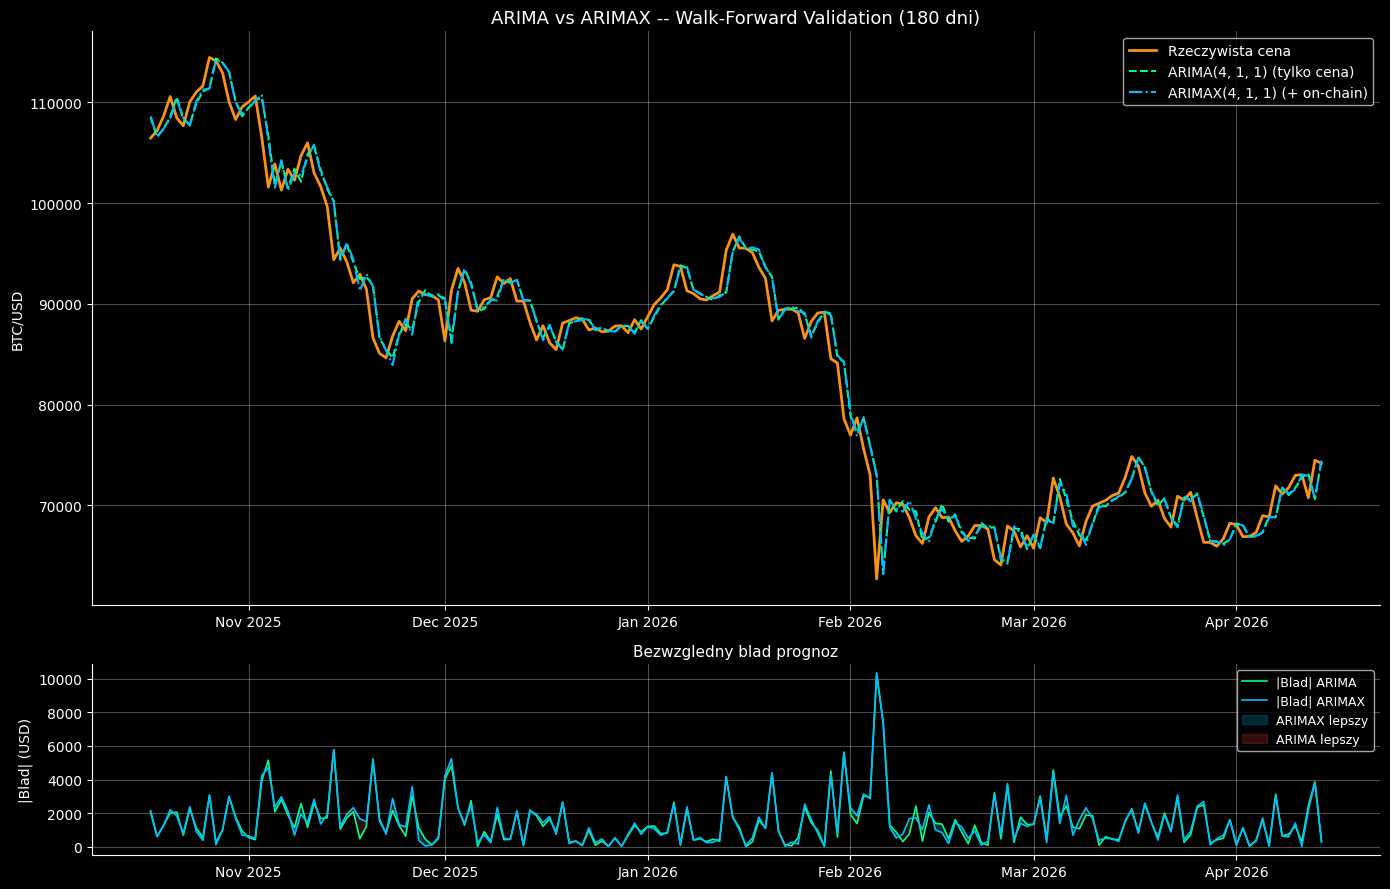

In [37]:
# Wykres ARIMA vs ARIMAX
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(test_common.index, test_common.values,
         color='#F7931A', lw=2, label='Rzeczywista cena')
ax1.plot(test_common.index, pred_arima_c.values,
         color='#00FF88', lw=1.5, linestyle='--', label=f'ARIMA{BEST_ORDER} (tylko cena)')
ax1.plot(test_common.index, pred_arimax_c.values,
         color='#00BFFF', lw=1.5, linestyle='-.', label=f'ARIMAX{BEST_ORDER} (+ on-chain)')
ax1.set_title('ARIMA vs ARIMAX -- Walk-Forward Validation (180 dni)', fontsize=13)
ax1.set_ylabel('BTC/USD')
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax2 = axes[1]
err_arima  = np.abs(test_common.values - pred_arima_c.values)
err_arimax = np.abs(test_common.values - pred_arimax_c.values)
ax2.plot(test_common.index, err_arima,  color='#00FF88', lw=1.2, label='|Blad| ARIMA')
ax2.plot(test_common.index, err_arimax, color='#00BFFF', lw=1.2, label='|Blad| ARIMAX')
ax2.fill_between(test_common.index, err_arima, err_arimax,
                 where=err_arimax < err_arima, alpha=0.2, color='#00BFFF', label='ARIMAX lepszy')
ax2.fill_between(test_common.index, err_arima, err_arimax,
                 where=err_arimax >= err_arima, alpha=0.2, color='#FF4444', label='ARIMA lepszy')
ax2.set_title('Bezwzgledny blad prognoz', fontsize=11)
ax2.set_ylabel('|Blad| (USD)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../data/processed/arimax_vs_arima.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 17. Prognoza ARIMAX -- jutro (1 dzien naprzod)

> **Dlaczego ARIMAX prognozuje tylko 1 dzien?**
> lag=1 oznacza: jutrzejsza prognoza potrzebuje dzisiejszych danych on-chain -- ktore znamy.
> Dla prognozy za 2 dni potrzeba jutrzejszych on-chain -- ktorych jeszcze nie ma.
> Rozwiazanie na wiecej niz 1 dzien: LSTM/BiLSTM.

In [38]:
# Finalny model ARIMAX -- trening na calych danych
print(f'Trenuje ARIMAX{BEST_ORDER} na {len(price_x)} obserwacjach...')
final_arimax = ARIMA(price_x, order=BEST_ORDER, exog=exog_sc).fit()
print('Gotowe.')
print()
print(f'  AIC: ARIMA={final_fit.aic:.2f}   ARIMAX={final_arimax.aic:.2f}')
print(f'  BIC: ARIMA={final_fit.bic:.2f}   ARIMAX={final_arimax.bic:.2f}')
print('  Nizsze AIC/BIC = lepsze dopasowanie')

# Prognoza jutro: exog = dzisiejsze wartosci (ostatni znany wiersz)
exog_tomorrow = exog_sc.iloc[[-1]].values
fc            = final_arimax.get_forecast(steps=1, exog=exog_tomorrow)
pred_tomorrow = fc.predicted_mean.iloc[0]
ci_tomorrow   = fc.conf_int(alpha=0.05)
change        = (pred_tomorrow / price_x.iloc[-1] - 1) * 100

print()
print('=' * 55)
print('       Prognoza ARIMAX -- JUTRO')
print('=' * 55)
print(f'  Ostatnia cena:       ${price_x.iloc[-1]:,.0f}  ({price_x.index[-1].date()})')
print(f'  Prognoza jutro:      ${pred_tomorrow:,.0f}')
print(f'  95% CI:              [${ci_tomorrow.iloc[0,0]:,.0f} ; ${ci_tomorrow.iloc[0,1]:,.0f}]')
print(f'  Prognozowana zmiana: {"+" if change>=0 else ""}{change:.2f}%')
print('=' * 55)

Trenuje ARIMAX(4, 1, 1) na 1795 obserwacjach...
Gotowe.

  AIC: ARIMA=31603.67   ARIMAX=31607.59
  BIC: ARIMA=31636.63   ARIMAX=31689.97
  Nizsze AIC/BIC = lepsze dopasowanie

       Prognoza ARIMAX -- JUTRO
  Ostatnia cena:       $74,182  (2026-04-14)
  Prognoza jutro:      $74,260
  95% CI:              [$71,121 ; $77,398]
  Prognozowana zmiana: +0.11%


---
## 18. Ktore zmienne on-chain maja najwiekszy wplyw?

Wspolczynniki modelu ARIMAX pokazuja liniowy wplyw kazdej zmiennej on-chain na cene BTC.
> Uwaga: to zaleznosci **korelacyjne**, nie przyczynowe.

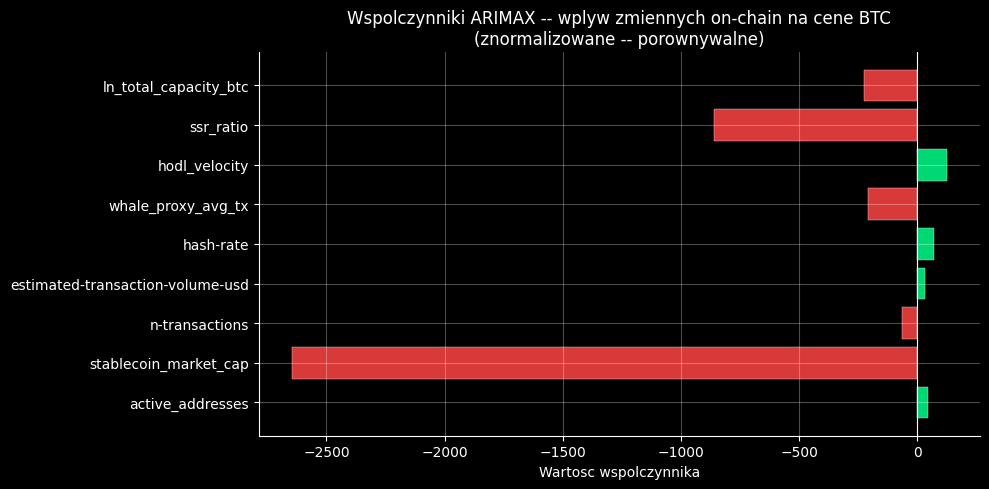

Interpretacja:
  Zielony (>0): wzrost zmiennej -> model prognozuje wzrost ceny
  Czerwony (<0): wzrost zmiennej -> model prognozuje spadek ceny

Ranking wplywu (wartosc absolutna):
  1. stablecoin_market_cap                      -2647.8279  (spadek ceny)
  2. ssr_ratio                                  -858.6290  (spadek ceny)
  3. ln_total_capacity_btc                      -225.8933  (spadek ceny)
  4. whale_proxy_avg_tx                         -210.0403  (spadek ceny)
  5. hodl_velocity                              +125.7913  (wzrost ceny)
  6. hash-rate                                  +68.0153  (wzrost ceny)
  7. n-transactions                             -63.5547  (spadek ceny)
  8. active_addresses                           +43.0454  (wzrost ceny)
  9. estimated-transaction-volume-usd           +30.0429  (wzrost ceny)


In [39]:
# Wspolczynniki ARIMAX
params      = final_arimax.params
exog_params = {col: params.get(col, 0) for col in EXOG_COLS}

fig, ax = plt.subplots(figsize=(10, 5))
cols   = list(exog_params.keys())
vals   = list(exog_params.values())
colors = ['#00FF88' if v >= 0 else '#FF4444' for v in vals]
bars   = ax.barh(cols, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='white', lw=0.8)
ax.set_title('Wspolczynniki ARIMAX -- wplyw zmiennych on-chain na cene BTC\n(znormalizowane -- porownywalne)', fontsize=12)
ax.set_xlabel('Wartosc wspolczynnika')
plt.tight_layout()
plt.savefig('../data/processed/arimax_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print('Interpretacja:')
print('  Zielony (>0): wzrost zmiennej -> model prognozuje wzrost ceny')
print('  Czerwony (<0): wzrost zmiennej -> model prognozuje spadek ceny')
print()
print('Ranking wplywu (wartosc absolutna):')
ranked = sorted(exog_params.items(), key=lambda x: abs(x[1]), reverse=True)
for i, (col, val) in enumerate(ranked, 1):
    direction = 'wzrost ceny' if val > 0 else 'spadek ceny'
    print(f'  {i}. {col:<42} {val:+.4f}  ({direction})')

In [40]:
# Finalne podsumowanie
print('=' * 68)
print('           FINALNE PODSUMOWANIE -- ARIMA vs ARIMAX')
print('=' * 68)
print()
print(f'{"Model":<10} {"MAPE":>8} {"MAE":>12} {"RMSE":>12} {"Dir.Acc":>10} {"AIC":>10}')
print('-' * 60)
print(f'{"ARIMA":<10} {m_arima["MAPE"]:>7.2f}% ${m_arima["MAE"]:>10,.0f} ${m_arima["RMSE"]:>10,.0f} {m_arima["DA"]:>9.1f}% {final_fit.aic:>10.1f}')
print(f'{"ARIMAX":<10} {m_arimax["MAPE"]:>7.2f}% ${m_arimax["MAE"]:>10,.0f} ${m_arimax["RMSE"]:>10,.0f} {m_arimax["DA"]:>9.1f}% {final_arimax.aic:>10.1f}')
print()
print('Dane on-chain uzyte w ARIMAX:')
for col in EXOG_COLS:
    print(f'  * {col}')
print()
print('Ograniczenia ARIMAX:')
print('  * Prognoza wielodniowa wymaga tez prognozowania danych on-chain')
print('  * Zaklada LINIOWY wplyw kazdej zmiennej na cene')
print('  * Nie modeluje interakcji miedzy zmiennymi on-chain')
print()
print('Co dalej -- LSTM/BiLSTM:')
print('  * Przyjma ten sam zestaw 9+ zmiennych on-chain')
print('  * Naucza sie NIELINIOWYCH zaleznosci i interakcji')
print('  * Moga prognozowac wszystkie horyzonty (1d-180d)')
print('=' * 68)

           FINALNE PODSUMOWANIE -- ARIMA vs ARIMAX

Model          MAPE          MAE         RMSE    Dir.Acc        AIC
------------------------------------------------------------
ARIMA         1.85% $     1,517 $     2,104      52.0%    31603.7
ARIMAX        1.89% $     1,548 $     2,138      52.0%    31607.6

Dane on-chain uzyte w ARIMAX:
  * active_addresses
  * stablecoin_market_cap
  * n-transactions
  * estimated-transaction-volume-usd
  * hash-rate
  * whale_proxy_avg_tx
  * hodl_velocity
  * ssr_ratio
  * ln_total_capacity_btc

Ograniczenia ARIMAX:
  * Prognoza wielodniowa wymaga tez prognozowania danych on-chain
  * Zaklada LINIOWY wplyw kazdej zmiennej na cene
  * Nie modeluje interakcji miedzy zmiennymi on-chain

Co dalej -- LSTM/BiLSTM:
  * Przyjma ten sam zestaw 9+ zmiennych on-chain
  * Naucza sie NIELINIOWYCH zaleznosci i interakcji
  * Moga prognozowac wszystkie horyzonty (1d-180d)
